In [6]:
import numpy as np

from config import PLOTS_DIR
from core.dgp import IIDProcess, NormalInnov, SkewTInnov, ARProcess, StudentTInnov, GARCHProcess, ARGARCHProcess
from core.models import IIDNormalModel, IIDNonNormalModel, AR1NormalModel, AR1NonNormalModel, GARCH11Model, AR1GARCH11SymmModel
from core.bias_correction_comp import run_bias_comp

In [7]:
N    = 5_000
Ts   = [15, 30, 50, 100, 300]

In [8]:
folder = PLOTS_DIR / "bias"
configs = [
#     (IIDProcess(NormalInnov()).calibrate_params(mu=0.5, sigma=1), 
#           IIDNormalModel(), folder/"iidnormal.png"),
#     (IIDProcess(SkewTInnov(df=6, eta=-0.5)).calibrate_params(mu=0.5, sigma=1), 
#            IIDNonNormalModel(), folder/"iidnonnormal.png"),
#     (ARProcess(phi=0.6, innov=NormalInnov()).calibrate_params(mu=0.5, sigma=1), 
#           AR1NormalModel(), folder/"arnormal.png"),
#     (ARProcess(phi=0.6, innov=StudentTInnov(df=6)).calibrate_params(mu=0.5, sigma=1), 
#           AR1NonNormalModel(), folder/"arnonnormal.png"),
    # (GARCHProcess(mu=0.05, omega=0.05, alpha=0.10, beta=0.85, dist="normal").calibrate_params(mu=0.5, sigma=1), 
    #       GARCH11Model(), folder/"garch.png"),
    (ARGARCHProcess(phi=0.6).calibrate_params(mu=0.5, sigma=1), 
          AR1GARCH11SymmModel(), folder/"argarch.png"),
]

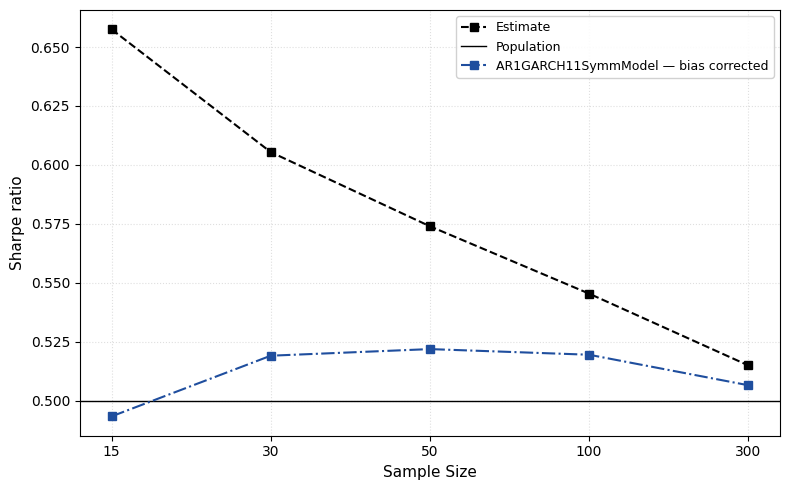

In [9]:
for config in configs:
    run_bias_comp(0.5, N, Ts, 
                  dgp=config[0], models=[config[1],], savefig=config[2], 
                  th_moments=True)

In [1]:
from pathlib import Path

from config import RESULTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [5]:
from core.dgp import IIDProcess, NormalInnov, SkewTInnov, ARProcess, StudentTInnov, GARCHProcess, ARGARCHProcess
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES: dict[str, callable] = {
    "iid_normal": (lambda **kwargs: IIDProcess(NormalInnov())),
    "iid_skewt6_m05": (lambda **kwargs: IIDProcess(SkewTInnov(df=6, eta=-0.5))),
    "ar1_06_normal": (lambda **kwargs: ARProcess(phi=0.6, innov=NormalInnov())),
    "ar1_06_t6": (lambda **kwargs: ARProcess(phi=0.6, innov=StudentTInnov(df=6))),
    "garch_normal": (lambda **kwargs: GARCHProcess(mu=0.05, omega=0.05, alpha=0.10, beta=0.85, dist="normal")),
    "ar_garch": (lambda **kwargs: ARGARCHProcess(phi=0.6)),
}
set_extra_dgps(DGP_EXAMPLES)

In [ ]:
# name : (dgp_names, model_short_names)
scenarios = {
    "bias_iid_normal": (
        ["iid_normal"],
        ["iid_normal"],
    ),
    "bias_iid_nonnormal": (
        ["iid_skewt6_m05"],
        ["iid_nonnormal"],
    ),
    "bias_ar_normal": (
        ["ar1_06_normal"],
        ["ar1_normal"],
    ),
    "bias_ar_nonnormal": (
        ["ar1_06_t6"],
        ["ar1_nonnormal"],
    ),
    "bias_garch": (
        ["garch_normal"],
        ["garch11"],
    ),
    "bias_argarch": (
        ["ar_garch"],
        ["ar1_garch11symm"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [15, 30 , 50, 200],
    "n_sim": [1_000, 10_000, 50_000],
}

In [4]:
N_SIM  = 50_000
N_JOBS = 8

experiments = {
    "bias_iid_normal": ExperimentSpec(
        scenario   = scenarios["bias_iid_normal"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = [True, False],
    ),
    "bias_iid_nonnormal": ExperimentSpec(
        scenario   = scenarios["bias_iid_nonnormal"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = [True, False],
    ),
    "bias_ar_normal": ExperimentSpec(
        scenario   = scenarios["bias_ar_normal"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = [True, False],
    ),
    "bias_ar_nonnormal": ExperimentSpec(
        scenario   = scenarios["bias_ar_nonnormal"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = [True, False],
    ),
    "bias_garch": ExperimentSpec(
        scenario   = scenarios["bias_garch"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = [True, False],
    ),
}

In [5]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"bias_iid_normal",
        #"bias_iid_nonnormal",
        #"bias_ar_normal",
        #"bias_ar_nonnormal",
        "bias_garch",
    ],
)


  Experiment: bias_garch
  [1/8]  T=15  bias_adj=True  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/8]  T=30  bias_adj=True  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/8]  T=50  bias_adj=True  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [4/8]  T=200  bias_adj=True  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [5/8]  T=15  bias_adj=False  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [6/8]  T=30  bias_adj=False  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [7/8]  T=50  bias_adj=False  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [8/8]  T=200  bias_adj=False  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE


In [6]:
#common
line_plot_kargs = dict(markers = ['D', 's', 'o', 'X', 'v'],
                       linewidth=1,
                       xticks=parameters['T'], log=True
                       )

In [7]:
folder = RESULTS_DIR / "scenarios"

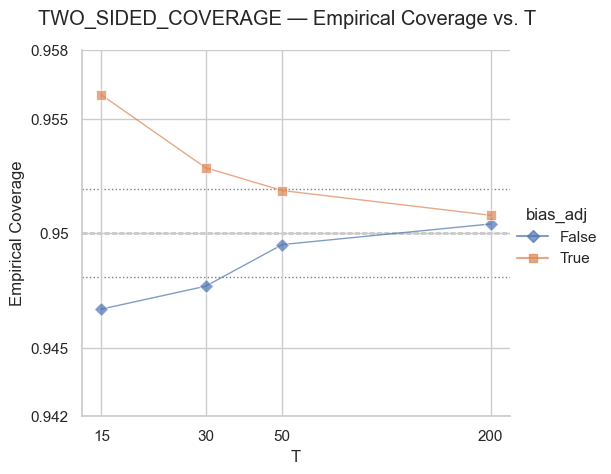

In [8]:
run_analysis(experiments, "bias_iid_normal", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(yticks=[0.958,0.955,0.950,0.945,0.942]))

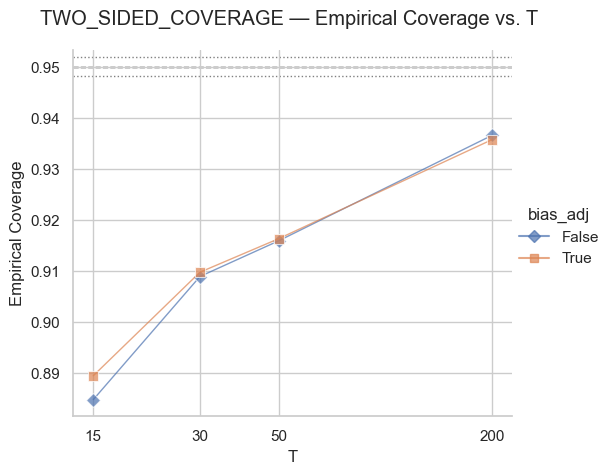

In [9]:
run_analysis(experiments, "bias_iid_nonnormal", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)

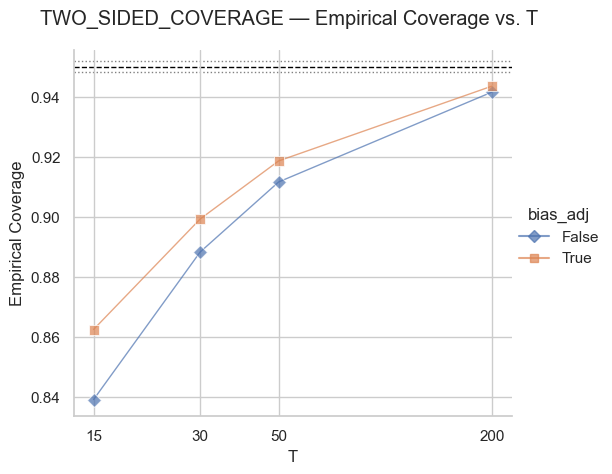

In [10]:
run_analysis(experiments, "bias_ar_normal", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)

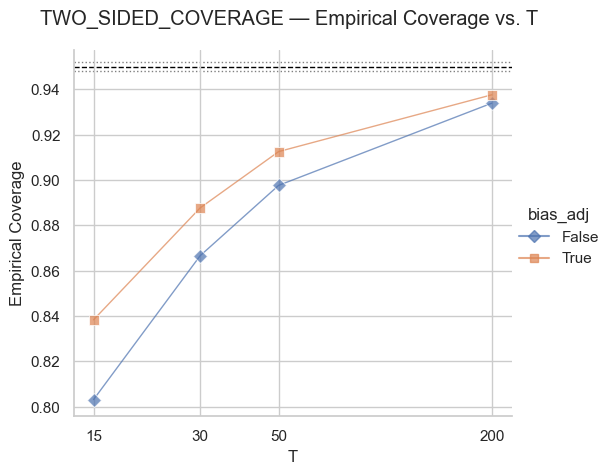

In [11]:
run_analysis(experiments, "bias_ar_nonnormal", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)

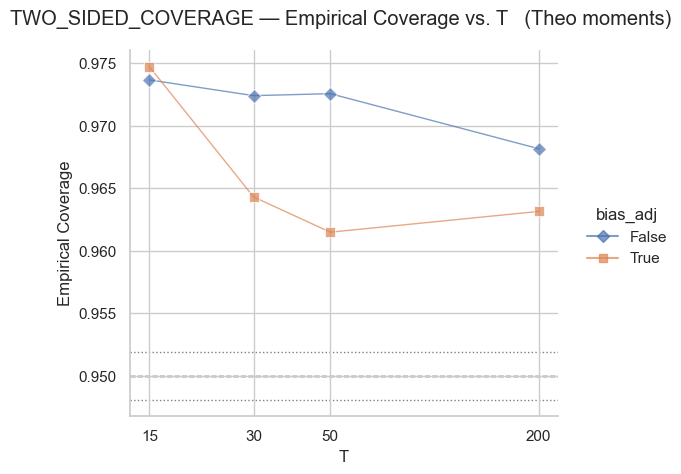

In [8]:
run_analysis(experiments, "bias_garch", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs)